# Advanced Tasks in Medical Informatics Using Arrays

In this notebook, you will tackle advanced problems related to medical informatics. Each task involves working with arrays and multidimensional arrays to solve real-world problems. Follow the instructions carefully and complete the sub-tasks as specified.

### Table of Contents
- [1. Patient Data Analysis](#1-patient-data-analysis)
  - [Task 1: Analyze Patient Vital Signs](#task-1-analyze-patient-vital-signs)
  - [Task 2: Detect Outliers in Lab Results](#task-2-detect-outliers-in-lab-results)
- [2. Medical Image Processing](#2-medical-image-processing)
  - [Task 3: Image Segmentation](#task-3-image-segmentation)
  - [Task 4: Image Enhancement](#task-4-image-enhancement)
- [3. Time Series Analysis](#3-time-series-analysis)
  - [Task 5: Analyze ECG Data](#task-5-analyze-ecg-data)
  - [Task 6: Predicting Patient Health Trends](#task-6-predicting-patient-health-trends)


## 1. Patient Data Analysis

### Task 1: Analyze Patient Vital Signs

You are provided with a dataset of patient vital signs, including heart rate, blood pressure, and temperature. Each patient's data is represented as a multidimensional array.

#### Instructions:
1. Load the dataset into a numpy array. Assume the data is in a CSV file named `vital_signs.csv` with columns: `Patient_ID`, `Heart_Rate`, `Blood_Pressure_Systolic`, `Blood_Pressure_Diastolic`, `Temperature`.
2. Calculate and print the mean and standard deviation for each vital sign across all patients.
3. Identify patients with heart rates outside the normal range (60-100 bpm). Print the `Patient_ID`s and their heart rates.
4. Identify patients with blood pressure readings classified as hypertensive (Systolic > 140 or Diastolic > 90). Print the `Patient_ID`s and their readings.
5. Identify patients with abnormal temperatures (below 95°F or above 99°F). Print the `Patient_ID`s and their temperatures.

In [18]:
# Task 1: Analyze Patient Vital Signs
import numpy as np
import pandas as pd

# Define multi dimensional array ['Heart_Rate', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Temperature'] per patient
vital_signs = np.array([[72, 120, 80, 98.6],
                        [88, 130, 85, 99.1],
                        [68, 115, 75, 97.9],
                        [76, 118, 78, 98.2],
                        [54, 122, 82, 99.5],
                        [90, 125, 66, 99.7],
                        [62, 110, 72, 97.4],
                        [80, 128, 84, 98.9],
                        [70, 182, 76, 98.0],
                        [78, 120, 80, 98.4]])

# Calculate mean and standard deviation
mean_vital_signs = np.mean(vital_signs, axis=0)
std_vital_signs = np.std(vital_signs, axis=0)
print('Mean Vital Signs:', mean_vital_signs)
print('Standard Deviation of Vital Signs:', std_vital_signs)

# Identify patients with abnormal heart rates
heart_rate = vital_signs[:, 0]
abnormal_heart_rates = (heart_rate < 60) | (heart_rate > 100)
print('Patients with abnormal heart rates:', np.where(abnormal_heart_rates)[0]+1)

# Identify patients with hypertensive blood pressure
systolic = vital_signs[:, 1]
diastolic = vital_signs[:, 2]
hypertensive_bp = (systolic >= 140) | (diastolic >= 90)
print('Patients with hypertensive blood pressure:', np.where(hypertensive_bp)[0]+1)

# Identify patients with fever
temperature = vital_signs[:, 3]
fever = temperature > 98.6
print('Patients with fever:', np.where(fever)[0]+1)


Mean Vital Signs: [ 73.8  127.    77.8   98.57]
Standard Deviation of Vital Signs: [10.52425769 19.17289754  5.49181209  0.69577295]
Patients with abnormal heart rates: [5]
Patients with hypertensive blood pressure: [9]
Patients with fever: [2 5 6 8]


### Task 2: Detect Outliers in Lab Results

You have lab results for a group of patients, including various test results like cholesterol levels, blood glucose, and hemoglobin. Each patient's results are stored in a multidimensional array.

#### Instructions:
1. Define a dataset into a numpy array. Assume the data is in a named with columns: `Patient_ID`, `Cholesterol`, `Blood_Glucose`, `Hemoglobin`.
2. For each test, calculate the Z-score and identify outliers (Z-score > 3 or Z-score < -3).
3. Print the `Patient_ID` (ROW) and their test results for each outlier.

In [16]:
# Task 2: Detect Outliers in Lab Results
from scipy import stats
import numpy as np

# Define lab results ['Patiend_ID','Cholesterol', 'Blood_Glucose', 'Hemoglobin'] per patient
columns = ['Patient_ID', 'Cholesterol', 'Blood_Glucose', 'Hemoglobin']
results = np.array([[1, 170, 80, 13.5],
                    [2, 190, 85, 14.2],
                    [3, 185, 90, 13.0],
                    [4, 200, 88, 14.8],
                    [5, 210, 98, 13.2],
                    [6, 160, 75, 12.5],
                    [7, 220, 100, 15.0],
                    [8, 240, 105, 14.5],
                    [9, 230, 93, 13.8],
                    [10, 25.0, 110, 15.2]])

# Calculate Z-scores
z_scores = np.abs(stats.zscore(results, axis=0))
outliers = (z_scores > 2)

# Print outliers
outlier_indices = np.where(outliers)[0]
for outlier in outlier_indices:
    print(f'Outlier: {columns[np.where(outliers[outlier])[0][0]]} for Patient {int(results[outlier][0])} with Z-score {z_scores[outlier][np.where(outliers[outlier])[0][0]]}')


Outlier: Cholesterol for Patient 10 with Z-score 2.727382885050915


## 2. Medical Image Processing

### Task 3: Image Segmentation

You are provided with a series of medical images in a numpy array. Your task is to segment a specific region of interest (ROI) in the images using a thresholding technique.

#### Instructions:
1. Load the image data into a numpy array. Assume the data is in a file named `medical_images.npy`.
2. Apply a threshold to segment the region of interest. For simplicity, use a threshold value to identify areas of interest.
3. Display the segmented images alongside the original images.
4. Save the segmented images to disk.

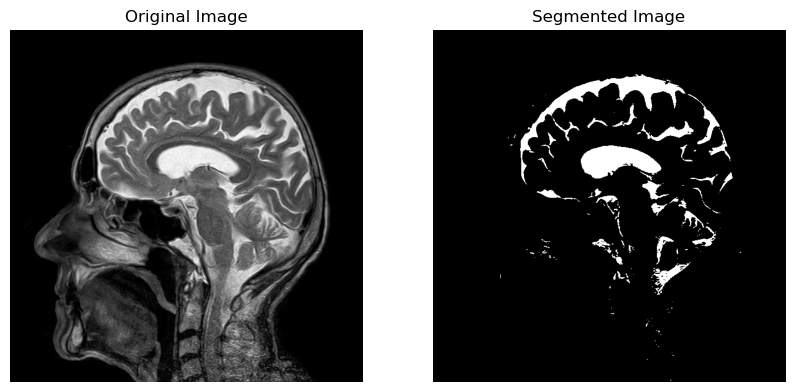

In [1]:
# Task 3: Image Segmentation
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Open the image file
image = Image.open('../Data/images/mri.jpg')

# Convert the image to a NumPy array
image = np.array(image)

# convert to grayscale
image = image.mean(axis=2)

# Define threshold value
threshold = 180  # Example threshold value

# Apply threshold to segment images
segmented_image = image > threshold

# Display original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title('Segmented Image')
plt.axis('off')
plt.show()

### Task 4: Crop Image

You have a medical image that need to be cropped for better visualization. Your task is to enhance the images by cropping the relevant regions.

#### Instructions:
1. Load the image data into a numpy array. Assume the data is in a file named `mri.jpg`.
2. Crop the images to focus on the relevant regions of interest. You can specify the coordinates for cropping.  
3. Display the original and cropped images side by side.
4. Save the cropped images to disk.

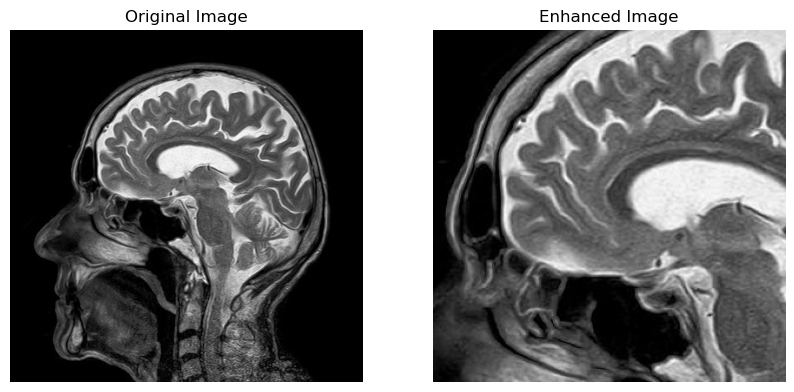

In [19]:
# Task 4: Crop Image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Open the image file
image = Image.open('../../images/mri.jpg')

# Convert the image to a NumPy array
image = np.array(image)

# convert to grayscale
image = image.mean(axis=2)

# Crop the image
croped_image = image[100:400, 100:400]

# Display original and enhanced images after cropping
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(croped_image, cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')
plt.show()


#### HINTS:
- You can use libraries like `numpy`, `matplotlib`, and `opencv` to solve these tasks.
- For image processing tasks, you can use the `opencv` library to load, process, and save images.   
- Make sure to provide any assumptions you make while solving the tasks.
- You can use the sample data provided below to test your implementations.
- Feel free to add more tasks or sub-tasks to the notebook.

## 3. Array calculations and manipulations 
They are the key to solving these tasks. Good Luck! 🚀

### Task 5: Patient Temperature Monitoring

**Story:**
Dr. Smith is monitoring the daily temperature readings of patients in an intensive care unit. Each patient has their temperature recorded every hour throughout the day. Due to a malfunction, the temperature sensor system recorded the same data twice. Dr. Smith needs to determine if there are any discrepancies in the temperature readings.

**Task:**
Given two matrices `T1` and `T2`, each representing the hourly temperature readings for a set of patients over 24 hours, write a program to compute the discrepancies in the temperature readings for each patient.

- **Input:** Two 24xN matrices `T1` and `T2`, where `N` is the number of patients. Each element in the matrices represents the temperature reading at a particular hour for a specific patient.
- **Output:** A 24xN matrix containing the discrepancies in the temperature readings for each patient. The discrepancy is calculated as the absolute difference between the two temperature readings for each hour.

**Solution Methods:**

1. **Nested For Loops**: Iterate through each element of the matrices, compute the differences of the corresponding elements, and store the results in a new matrix.
2. **Array Calculations**: Use NumPy to calculate the discrepancies directly through array operations.

#### Example Code: Using Nested For Loops

In [22]:
import numpy as np

# Example input: Two matrices with hourly temperature readings for 3 patients over 24 hours
T1 = np.random.rand(24, 3) * 10 + 36  # Random temperatures between 36 and 46 degrees Celsius
T2 = T1 + np.random.randn(24, 3)  # Add some random noise to the temperatures

# Initialize an empty matrix to store the average temperatures
average_temp_loops = np.zeros((24, 3))

# Calculate the absolut differences temperature using nested loops
for i in range(24):
    for j in range(3):
        average_temp_loops[i][j] = np.abs(T1[i][j] - T2[i][j])

print("Average Temperature using nested loops:")
print(average_temp_loops)

Average Temperature using nested loops:
[[39.23370616 39.70466763 43.96785208]
 [42.07462542 42.24087037 43.6052818 ]
 [43.33752182 41.07401758 40.65190271]
 [38.22498057 40.2788218  40.97696921]
 [44.967206   40.12652933 39.46493913]
 [40.54540664 39.13294137 44.3371974 ]
 [40.23930527 43.87312651 38.09000948]
 [39.46769829 39.93713205 42.28393658]
 [40.79070578 42.96486847 43.12838999]
 [42.79762773 43.10788188 39.46243005]
 [37.43734765 42.37630838 39.16127781]
 [42.10134202 43.17397026 41.77507568]
 [41.27191085 39.72013531 40.74671476]
 [40.94964767 40.52391467 37.54629256]
 [40.23367454 41.22356479 41.5869878 ]
 [37.51943138 38.76660617 44.77045176]
 [43.04319173 43.95100729 38.78539747]
 [41.9743379  43.8441605  41.29502975]
 [41.45147267 44.58416841 39.59703518]
 [40.92005466 38.8663274  36.64259288]
 [41.93073498 41.21247635 41.46591612]
 [45.22321303 44.50447314 39.38567831]
 [38.97809464 42.09019021 39.42663852]
 [38.236211   40.05257082 37.53008869]]


#### Example Code: Using Array Calculations (Vectorized Operations)

In [24]:
# Calculate the absolut differences temperature using NumPy's array operations
average_temp_vectorized = np.abs(T1 - T2)

print("Average Temperature using array calculations:")
print(average_temp_vectorized)

Average Temperature using array calculations:
[[39.23370616 39.70466763 43.96785208]
 [42.07462542 42.24087037 43.6052818 ]
 [43.33752182 41.07401758 40.65190271]
 [38.22498057 40.2788218  40.97696921]
 [44.967206   40.12652933 39.46493913]
 [40.54540664 39.13294137 44.3371974 ]
 [40.23930527 43.87312651 38.09000948]
 [39.46769829 39.93713205 42.28393658]
 [40.79070578 42.96486847 43.12838999]
 [42.79762773 43.10788188 39.46243005]
 [37.43734765 42.37630838 39.16127781]
 [42.10134202 43.17397026 41.77507568]
 [41.27191085 39.72013531 40.74671476]
 [40.94964767 40.52391467 37.54629256]
 [40.23367454 41.22356479 41.5869878 ]
 [37.51943138 38.76660617 44.77045176]
 [43.04319173 43.95100729 38.78539747]
 [41.9743379  43.8441605  41.29502975]
 [41.45147267 44.58416841 39.59703518]
 [40.92005466 38.8663274  36.64259288]
 [41.93073498 41.21247635 41.46591612]
 [45.22321303 44.50447314 39.38567831]
 [38.97809464 42.09019021 39.42663852]
 [38.236211   40.05257082 37.53008869]]


### Task 6: Medical Imaging Pixel Correction

**Story:**
In a medical imaging lab, an X-ray machine malfunctioned during a scan, causing the pixel values in the resulting images to be erroneously too dark. To correct this, the radiologist needs to restore the images by windowing pixel values to the correct range.

**Task:**
Given one matrice `X1` representing the pixel values of an X-ray image captured, write a program to compute the corrected image by mapping the pixel values to a new range.

- **Input:**  A matrice `X1`, where each element represents a pixel value in the X-ray image.
- **Output:** An matrix containing the corrected pixel values for the X-ray image.

**Solution Method:**

1. **Nested For Loops**: Manually iterate over each pixel, remap the pixel values to the new range, and store the corrected values in a new matrix.
2. **Array Calculations**: Use NumPy to perform the pixel value remapping directly through array operations.

---

Both problems involve calculating the mapping of pixel values from one range to another. Solving these with nested loops would make the process explicit and easy to understand, while using array calculations would be more efficient, particularly for large datasets like medical images.

#### Example Code: Using Nested For Loops

In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Open the image file
image = Image.open('../Data/images/dark_mri.jpg')

# Convert the image to a NumPy array
image = np.array(image)


M, N = image.shape

# Get minimum and maximum pixel values
min_val = np.min(image)
max_val = np.max(image)

# Initialize an empty matrix to store the corrected image
corrected_image_loops = np.zeros((M, N), dtype=int)

# Calculate the corrected image using nested loops and linear scaling min-max normalization
for i in range(M):
    for j in range(N):
        corrected_image_loops[i][j] = (image[i][j]-min_val) *255 / (max_val - min_val)

# Convert the corrected image to uint8 data type
corrected_image_loops = corrected_image_loops.astype(np.uint8)

# save the corrected image
corrected_image_loops = Image.fromarray(corrected_image_loops, mode='L')
corrected_image_loops.save('../Data/images/mri_corrected_loops.jpg')

# Display original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(corrected_image_loops, cmap='gray', vmin=0, vmax=255)
plt.title('Windowed Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image+100, cmap='gray', vmin=0, vmax=255)
plt.title('Brighten Image')
plt.axis('off')
plt.show()

Corrected Image using nested loops:
[[131 240  90  21 115]
 [164  67 106  69 237]
 [ 35  68 168 198 107]
 [221  67 152 120 205]
 [109  75 119  67 171]]


#### Example Code: Using Array Calculations (Vectorized Operations)


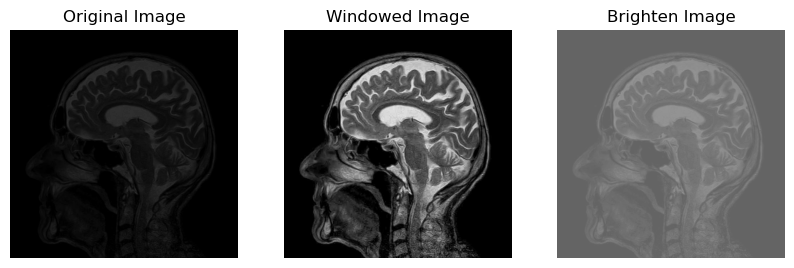

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Open the image file
image = Image.open('../Data/images/dark_mri.jpg')

# Convert the image to a NumPy array
image = np.array(image)

# Get minimum and maximum pixel values
min_val = np.min(image)
max_val = np.max(image)

# Calculate the corrected image using NumPy's array operations
corrected_image_vectorized = (image - min_val) * (255 / (max_val - min_val))

# Convert the corrected image to uint8 data type
corrected_image_vectorized = corrected_image_vectorized.astype(np.uint8)

# save the corrected image
corrected_image_vectorized = Image.fromarray(corrected_image_vectorized, mode='L')
corrected_image_vectorized.save('../Data/images/mri_corrected_vectorized.jpg')

# Display original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(corrected_image_vectorized, cmap='gray', vmin=0, vmax=255)
plt.title('Windowed Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image+100, cmap='gray', vmin=0, vmax=255)
plt.title('Brighten Image')
plt.axis('off')
plt.show()

### Explanation

- **Nested For Loops:** The loops iterate through each element of the matrices to calculate the mapping of pixel values. This method is simple but can be slow, especially for large matrices.
  
- **Array Calculations:** NumPy's vectorized operations allow us to perform the same task in a single line. This method is not only more concise but also significantly faster, particularly when dealing with large datasets like medical images.

Each method has its advantages and use cases. While nested loops are easier to understand and implement, array calculations are more efficient and suitable for large datasets. Depending on the size of the dataset and the complexity of the operation, you can choose the appropriate method for your task.


